# ObjectNav Goal Distance Analysis

Comparing distance metrics for defining episode success in Habitat ObjectNav.

**Context:** The Habitat ObjectNav challenge defines success as the agent being within
a threshold distance of the target object. However, there are multiple ways to measure this:

| Metric | Description | Habitat config |
|--------|-------------|----------------|
| `distance_to_goal` (viewpoint) | Geodesic distance to nearest pre-computed viewpoint | `distance_to: VIEW_POINTS`, `success_distance: 0.1` |
| Object centroid (3D) | 3D Euclidean distance to nearest object centroid | Challenge website: "1.0m from any instance" |
| Object centroid (2D) | Horizontal Euclidean distance (ignoring height) | Removes height bias |

**Data:** `output/goal_distance_analysis.pkl` — 30 val_mini episodes, each run with
`ShortestPathFollower` (goal_radius=0.01) recording all three metrics at every step.

**Goal:** Choose the right metric and threshold for our DreamerV3 wrapper.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

with open("../../../output/goal_distance_analysis.pkl", "rb") as f:
    raw_data = pickle.load(f)

# Data has two modes: 'viewpoint' and 'object_centroid'
if isinstance(raw_data, dict):
    episodes = raw_data['viewpoint']  # default for existing analysis
    episodes_obj = raw_data['object_centroid']
    print(f"Loaded {len(episodes)} episodes (viewpoint mode)")
    print(f"Loaded {len(episodes_obj)} episodes (object-centroid mode)")
else:
    episodes = raw_data
    episodes_obj = None
    print(f"Loaded {len(episodes)} episodes")
print(f"Categories: {sorted(set(ep['category'] for ep in episodes))}")

Loaded 30 episodes (viewpoint mode)
Loaded 30 episodes (object-centroid mode)
Categories: ['bed', 'chair', 'plant', 'sofa', 'toilet', 'tv_monitor']


## 1. Final distances when shortest-path follower stops

When the follower reaches its best position, how far is the agent from the goal
under each metric?

In [2]:
# Exclude episodes where follower clearly failed (vp > 1.0m = pathfinding error)
good_eps = [ep for ep in episodes if ep["final_dist_viewpoint"] < 1.0]
failed_eps = [ep for ep in episodes if ep["final_dist_viewpoint"] >= 1.0]
print(f"Follower reached goal: {len(good_eps)}/{len(episodes)} episodes")
if failed_eps:
    print(f"Failed episodes (pathfinding error): {[ep['episode_id'] for ep in failed_eps]}")

# Extract final distances
vp_dists = [ep["final_dist_viewpoint"] for ep in good_eps]
obj3d_dists = [ep["final_dist_object_3d"] for ep in good_eps]
obj2d_dists = [ep["final_dist_object_2d"] for ep in good_eps]
categories = [ep["category"] for ep in good_eps]

print(f"\n{'Metric':<25} {'Mean':>6} {'Std':>6} {'Min':>6} {'Max':>6} {'Median':>6}")
print("-" * 62)
for name, dists in [("Viewpoint (geodesic)", vp_dists),
                     ("Object centroid (3D)", obj3d_dists),
                     ("Object centroid (2D)", obj2d_dists)]:
    d = np.array(dists)
    print(f"{name:<25} {d.mean():>6.3f} {d.std():>6.3f} {d.min():>6.3f} {d.max():>6.3f} {np.median(d):>6.3f}")

Follower reached goal: 27/30 episodes
Failed episodes (pathfinding error): ['5', '0', '3']

Metric                      Mean    Std    Min    Max Median
--------------------------------------------------------------
Viewpoint (geodesic)       0.117  0.049  0.012  0.197  0.119
Object centroid (3D)       1.845  0.407  1.285  2.738  1.948
Object centroid (2D)       1.594  0.347  1.030  2.431  1.654


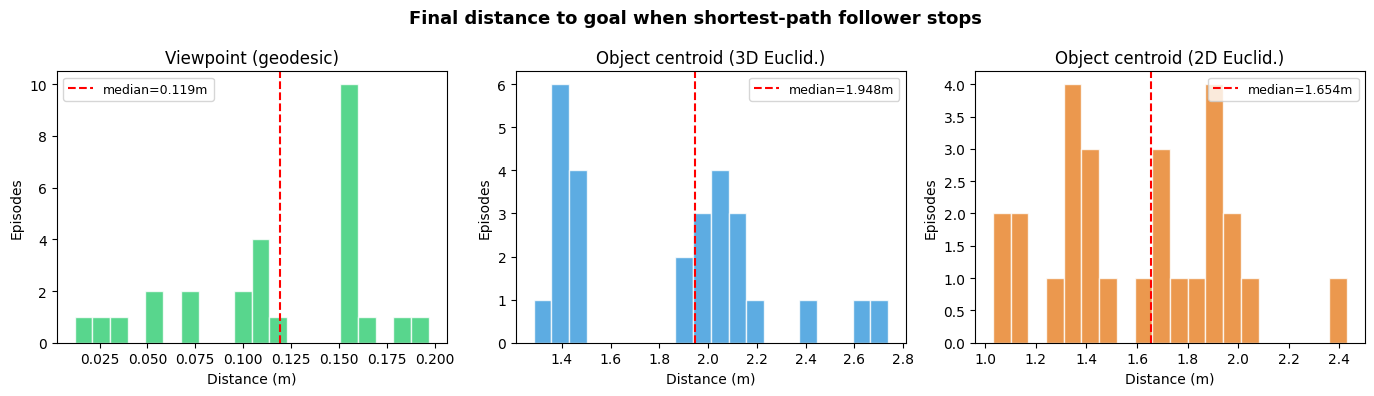

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, dists, color) in zip(axes, [
    ("Viewpoint (geodesic)", vp_dists, "#2ecc71"),
    ("Object centroid (3D Euclid.)", obj3d_dists, "#3498db"),
    ("Object centroid (2D Euclid.)", obj2d_dists, "#e67e22"),
]):
    ax.hist(dists, bins=20, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(np.median(dists), color="red", linestyle="--", linewidth=1.5,
               label=f"median={np.median(dists):.3f}m")
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Episodes")
    ax.set_title(name)
    ax.legend(fontsize=9)

fig.suptitle("Final distance to goal when shortest-path follower stops",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Why object-centric distance is always > 1.0m

Viewpoints are navigable positions where the agent can *see* the object.
They are not at the object itself. The height component also adds distance.

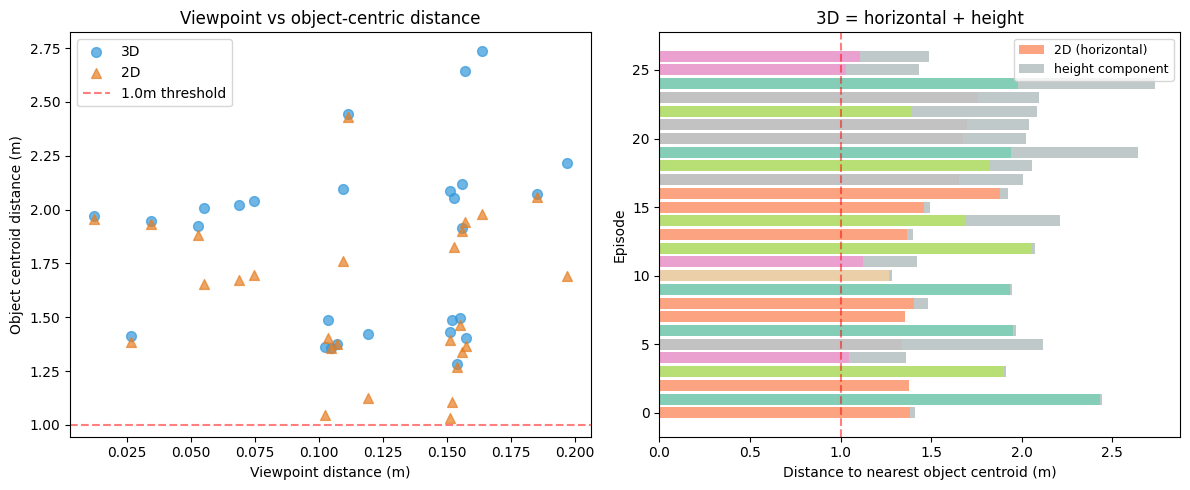

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: viewpoint dist vs object dist
ax = axes[0]
ax.scatter(vp_dists, obj3d_dists, c="#3498db", alpha=0.7, label="3D", s=50)
ax.scatter(vp_dists, obj2d_dists, c="#e67e22", alpha=0.7, label="2D", s=50, marker="^")
ax.axhline(1.0, color="red", linestyle="--", alpha=0.5, label="1.0m threshold")
ax.set_xlabel("Viewpoint distance (m)")
ax.set_ylabel("Object centroid distance (m)")
ax.set_title("Viewpoint vs object-centric distance")
ax.legend()

# Height offset contribution
ax = axes[1]
height_diffs = np.array(obj3d_dists) - np.array(obj2d_dists)
cat_order = sorted(set(categories))
cat_colors = plt.cm.Set2(np.linspace(0, 1, len(cat_order)))
cat_cmap = dict(zip(cat_order, cat_colors))
colors = [cat_cmap[c] for c in categories]
ax.barh(range(len(good_eps)), obj2d_dists, color=colors, alpha=0.8, label="2D (horizontal)")
ax.barh(range(len(good_eps)), height_diffs, left=obj2d_dists,
        color="#95a5a6", alpha=0.6, label="height component")
ax.axvline(1.0, color="red", linestyle="--", alpha=0.5)
ax.set_xlabel("Distance to nearest object centroid (m)")
ax.set_ylabel("Episode")
ax.set_title("3D = horizontal + height")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. Success rate vs threshold

For each metric, sweep the success threshold and compute what fraction
of shortest-path episodes would be classified as successful.

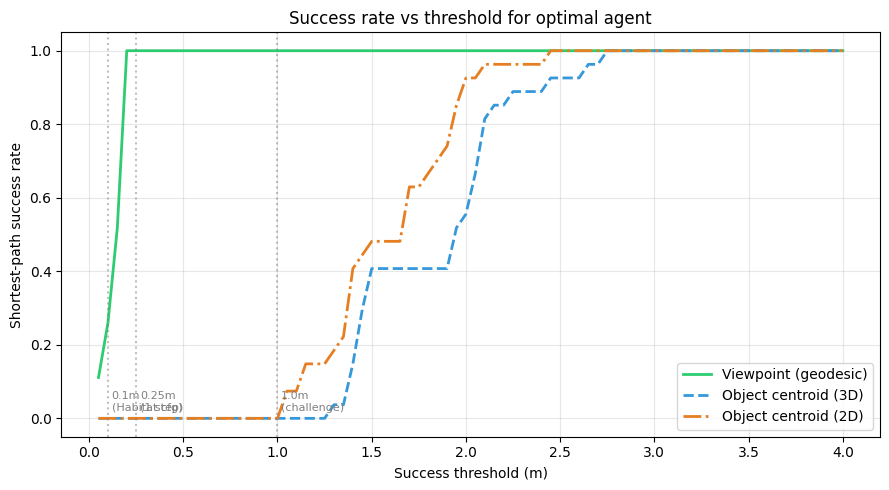

In [5]:
thresholds = np.arange(0.05, 4.05, 0.05)

fig, ax = plt.subplots(figsize=(9, 5))

for name, dists, color, ls in [
    ("Viewpoint (geodesic)", vp_dists, "#2ecc71", "-"),
    ("Object centroid (3D)", obj3d_dists, "#3498db", "--"),
    ("Object centroid (2D)", obj2d_dists, "#e67e22", "-."),
]:
    rates = [np.mean(np.array(dists) < t) for t in thresholds]
    ax.plot(thresholds, rates, color=color, linestyle=ls, linewidth=2, label=name)

# Mark key thresholds
ax.axvline(0.1, color="gray", linestyle=":", alpha=0.5)
ax.text(0.12, 0.02, "0.1m\n(Habitat cfg)", fontsize=8, color="gray")
ax.axvline(0.25, color="gray", linestyle=":", alpha=0.5)
ax.text(0.27, 0.02, "0.25m\n(1 step)", fontsize=8, color="gray")
ax.axvline(1.0, color="gray", linestyle=":", alpha=0.5)
ax.text(1.02, 0.02, "1.0m\n(challenge)", fontsize=8, color="gray")

ax.set_xlabel("Success threshold (m)")
ax.set_ylabel("Shortest-path success rate")
ax.set_title("Success rate vs threshold for optimal agent")
ax.legend(loc="lower right")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. SPL under different metric/threshold choices

Compute SPL for each episode under each candidate configuration.

In [6]:
def compute_spl(ep, dist_key, threshold):
    """Compute SPL for one episode given a distance metric and threshold."""
    final_dist = ep[f"final_{dist_key}"]
    success = 1.0 if final_dist < threshold else 0.0
    l = ep["start_geodesic"]
    p = ep["path_length"]
    if success > 0 and l > 0:
        return l / max(l, p)
    return 0.0


configs = [
    ("Viewpoint, 0.1m",  "dist_viewpoint", 0.1),
    ("Viewpoint, 0.2m",  "dist_viewpoint", 0.2),
    ("Viewpoint, 0.36m", "dist_viewpoint", 0.36),
    ("Object 3D, 1.0m",  "dist_object_3d", 1.0),
    ("Object 3D, 2.0m",  "dist_object_3d", 2.0),
    ("Object 3D, 3.0m",  "dist_object_3d", 3.0),
    ("Object 2D, 1.0m",  "dist_object_2d", 1.0),
    ("Object 2D, 1.5m",  "dist_object_2d", 1.5),
    ("Object 2D, 2.0m",  "dist_object_2d", 2.0),
]

print(f"{'Configuration':<22} {'SR':>6} {'Mean SPL':>10} {'Episodes':>10}")
print("-" * 52)
for name, key, thresh in configs:
    spls = [compute_spl(ep, key, thresh) for ep in good_eps]
    sr = np.mean([1 if s > 0 else 0 for s in spls])
    mean_spl = np.mean(spls)
    n_success = sum(1 for s in spls if s > 0)
    print(f"{name:<22} {sr:>5.0%} {mean_spl:>10.3f} {n_success:>5}/{len(good_eps)}")

Configuration              SR   Mean SPL   Episodes
----------------------------------------------------
Viewpoint, 0.1m          26%      0.238     7/27
Viewpoint, 0.2m         100%      0.870    27/27
Viewpoint, 0.36m        100%      0.870    27/27
Object 3D, 1.0m           0%      0.000     0/27
Object 3D, 2.0m          56%      0.507    15/27
Object 3D, 3.0m         100%      0.870    27/27
Object 2D, 1.0m           0%      0.000     0/27
Object 2D, 1.5m          48%      0.443    13/27
Object 2D, 2.0m          93%      0.828    25/27


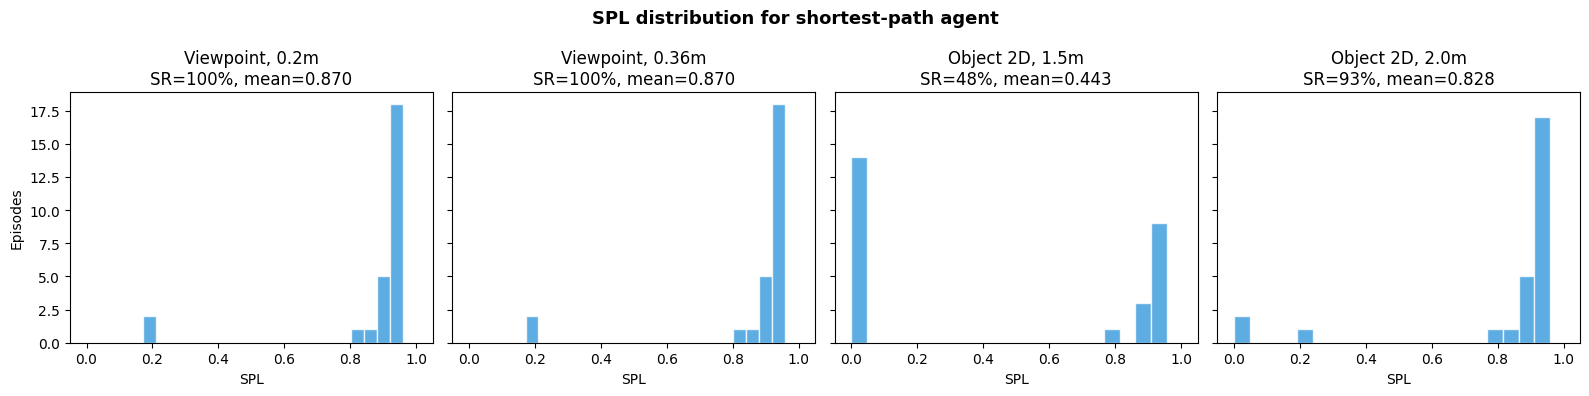

In [7]:
# Visualize SPL distributions for top candidates
top_configs = [
    ("Viewpoint, 0.2m",  "dist_viewpoint", 0.2),
    ("Viewpoint, 0.36m", "dist_viewpoint", 0.36),
    ("Object 2D, 1.5m",  "dist_object_2d", 1.5),
    ("Object 2D, 2.0m",  "dist_object_2d", 2.0),
]

fig, axes = plt.subplots(1, len(top_configs), figsize=(4 * len(top_configs), 4),
                         sharey=True)

for ax, (name, key, thresh) in zip(axes, top_configs):
    spls = [compute_spl(ep, key, thresh) for ep in good_eps]
    sr = np.mean([1 if s > 0 else 0 for s in spls])
    nonzero = [s for s in spls if s > 0]

    ax.hist(spls, bins=20, color="#3498db", alpha=0.8, edgecolor="white")
    ax.set_xlabel("SPL")
    ax.set_title(f"{name}\nSR={sr:.0%}, mean={np.mean(spls):.3f}")
    ax.set_xlim(-0.05, 1.05)

axes[0].set_ylabel("Episodes")
fig.suptitle("SPL distribution for shortest-path agent", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Per-category breakdown

Do certain object categories have systematically higher object-centroid distances?

/scratch/ipykernel_2922200/542216532.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=cat_names, patch_artist=True)
/scratch/ipykernel_2922200/542216532.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=cat_names, patch_artist=True)
/scratch/ipykernel_2922200/542216532.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=cat_names, patch_artist=True)


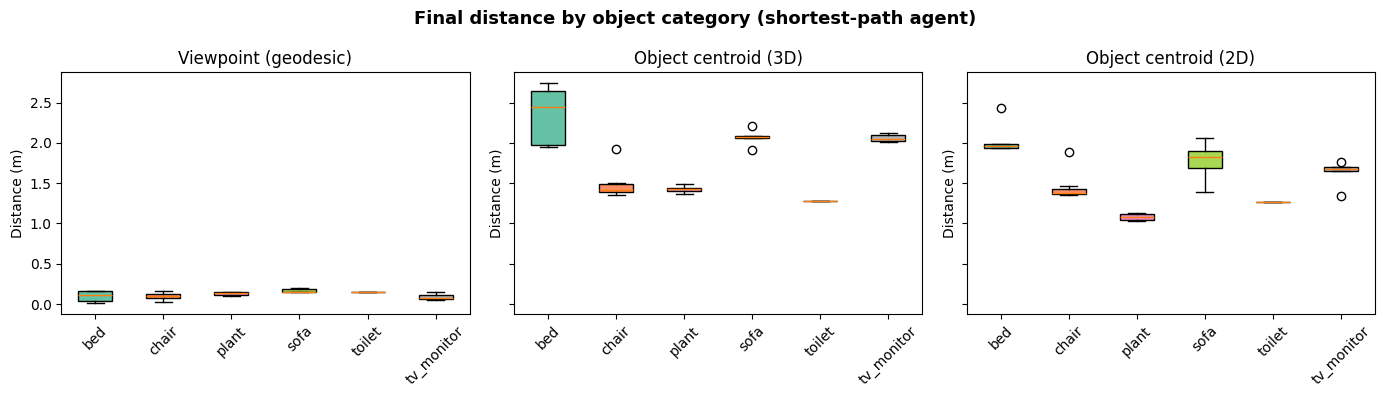

In [8]:
from collections import defaultdict

by_cat = defaultdict(list)
for ep in good_eps:
    by_cat[ep["category"]].append(ep)

cat_names = sorted(by_cat.keys())

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (title, key) in zip(axes, [
    ("Viewpoint (geodesic)", "final_dist_viewpoint"),
    ("Object centroid (3D)", "final_dist_object_3d"),
    ("Object centroid (2D)", "final_dist_object_2d"),
]):
    data = [[ep[key] for ep in by_cat[c]] for c in cat_names]
    bp = ax.boxplot(data, labels=cat_names, patch_artist=True)
    for patch, color in zip(bp["boxes"], plt.cm.Set2(np.linspace(0, 1, len(cat_names)))):
        patch.set_facecolor(color)
    ax.set_title(title)
    ax.set_ylabel("Distance (m)")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Final distance by object category (shortest-path agent)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Top-down maps: start, path, goal

Bird's-eye view (XZ plane) showing agent trajectory, object centroids,
and target viewpoint for selected episodes. This shows why object-centric
distance is always larger than viewpoint distance — the agent navigates to
a viewpoint *near* the object, not to the object itself.

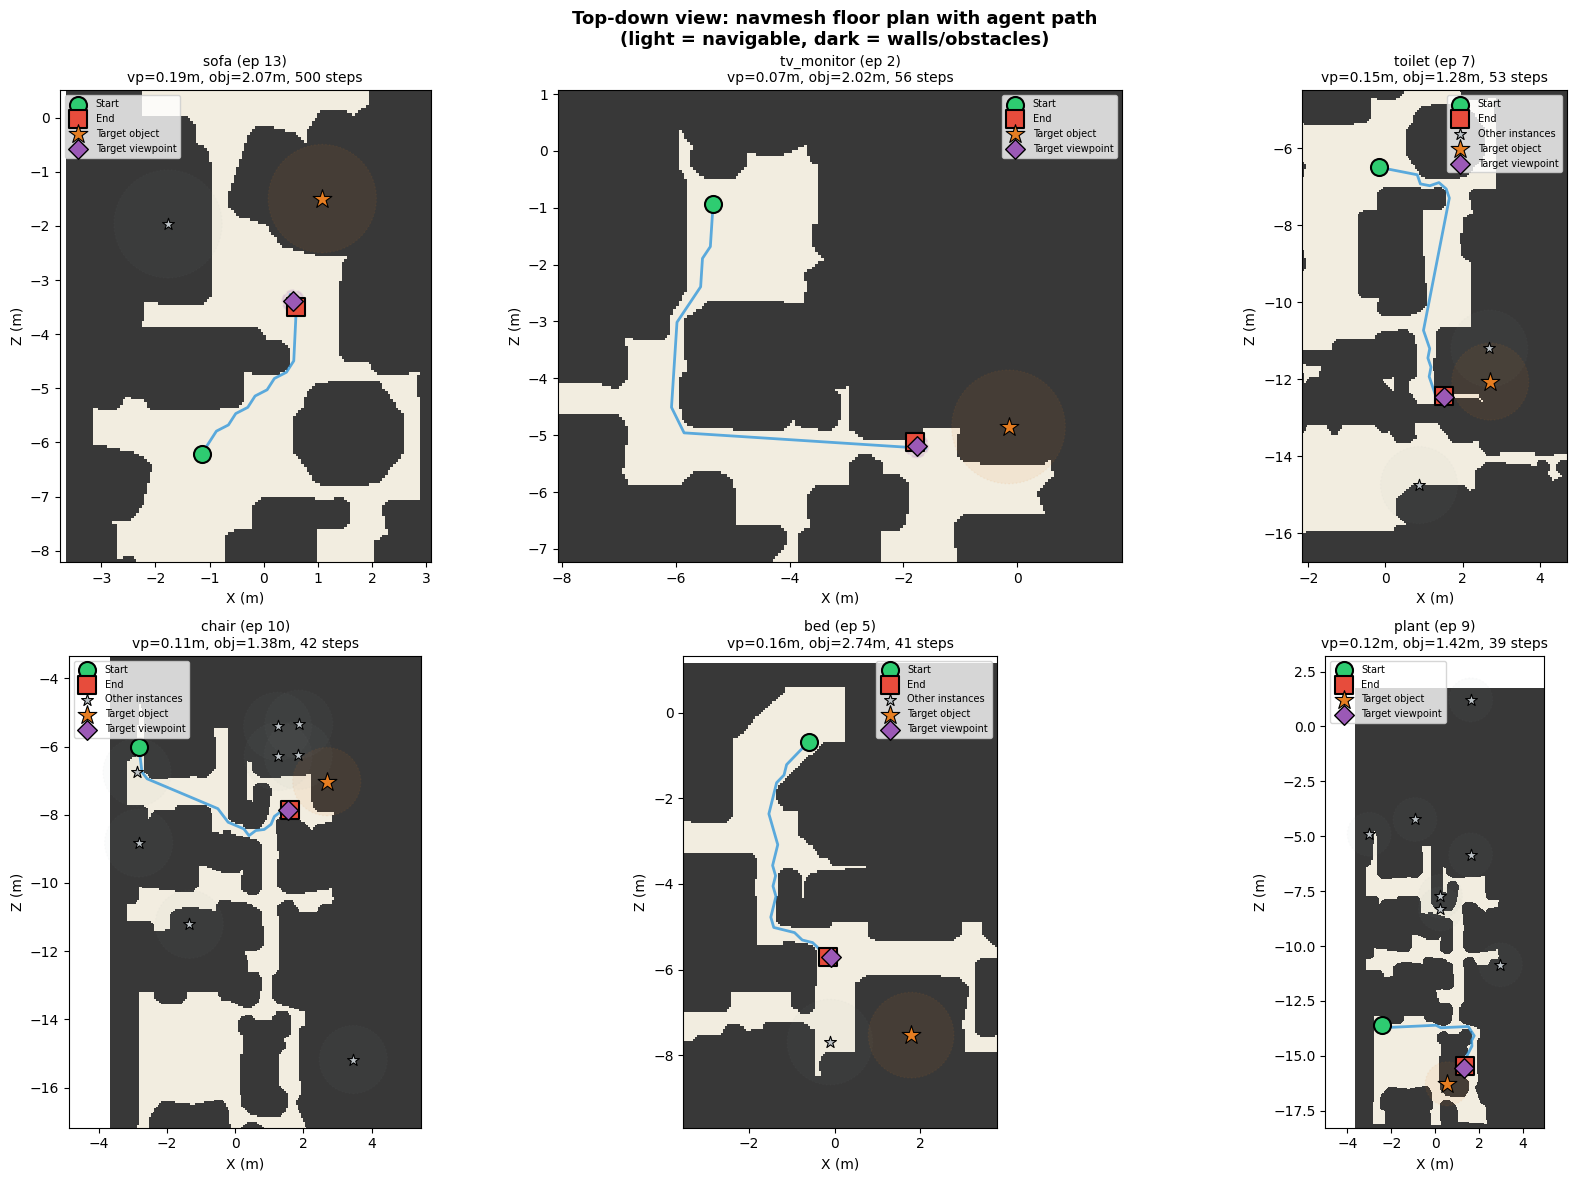

In [9]:
# Select 6 diverse episodes for top-down visualization
map_eps = []
seen = set()
for ep in sorted(good_eps, key=lambda e: e['n_steps'], reverse=True):
    if ep['category'] not in seen and ep['n_steps'] > 10 and ep.get('start_pos'):
        map_eps.append(ep)
        seen.add(ep['category'])
    if len(map_eps) >= 6:
        break

n = len(map_eps)
cols = min(n, 3)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
if n == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (ax, ep) in enumerate(zip(axes, map_eps)):
    steps = ep['steps']
    if not steps or 'agent_pos' not in steps[0]:
        ax.set_visible(False)
        continue

    # --- Navmesh floor plan ---
    nm = ep.get('navmesh')
    if nm is not None:
        grid = nm['grid']
        # Create RGB image: navigable = light beige, walls = dark gray
        floor_img = np.full((*grid.shape, 3), 0.22)  # dark background
        floor_img[grid] = [0.95, 0.93, 0.88]  # navigable = light beige
        ax.imshow(floor_img, origin='lower',
                  extent=[nm['x_min'], nm['x_max'], nm['z_min'], nm['z_max']],
                  aspect='equal', zorder=0, interpolation='nearest')

    # --- Agent trajectory (XZ) ---
    traj_x = [ep['start_pos'][0]] + [s['agent_pos'][0] for s in steps]
    traj_z = [ep['start_pos'][2]] + [s['agent_pos'][2] for s in steps]
    ax.plot(traj_x, traj_z, color='#3498db', linewidth=2, alpha=0.8, zorder=2)

    # --- Start position ---
    ax.scatter(ep['start_pos'][0], ep['start_pos'][2], color='#2ecc71',
               s=150, marker='o', zorder=5, edgecolors='black', linewidth=1.5,
               label='Start')

    # --- End position ---
    end_pos = steps[-1]['agent_pos']
    ax.scatter(end_pos[0], end_pos[2], color='#e74c3c',
               s=150, marker='s', zorder=5, edgecolors='black', linewidth=1.5,
               label='End')

    # --- All goal object centroids ---
    for gi, gp in enumerate(ep['goal_positions']):
        is_target = (gi == ep.get('target_goal_idx', -1))
        ax.scatter(gp[0], gp[2],
                   color='#e67e22' if is_target else '#bdc3c7',
                   s=200 if is_target else 80, marker='*', zorder=4,
                   edgecolors='black', linewidth=0.8,
                   label='Target object' if is_target else ('Other instances' if gi == 0 else None))
        # Draw radius circle around centroid
        circle = plt.Circle((gp[0], gp[2]), 1.0,
                            fill=True, alpha=0.08 if is_target else 0.04,
                            linestyle=':', linewidth=1,
                            color='#e67e22' if is_target else '#95a5a6')
        ax.add_patch(circle)

    # --- Target viewpoint ---
    if ep.get('target_viewpoint'):
        vp = ep['target_viewpoint']
        ax.scatter(vp[0], vp[2], color='#9b59b6',
                   s=100, marker='D', zorder=5, edgecolors='black', linewidth=1,
                   label='Target viewpoint')
        circle_vp = plt.Circle((vp[0], vp[2]), 0.2,
                               fill=True, alpha=0.15,
                               linestyle='--', linewidth=1.5,
                               color='#9b59b6')
        ax.add_patch(circle_vp)

    # --- Zoom to area of interest ---
    all_x = traj_x + [gp[0] for gp in ep['goal_positions']]
    all_z = traj_z + [gp[2] for gp in ep['goal_positions']]
    pad = 2.0
    ax.set_xlim(min(all_x) - pad, max(all_x) + pad)
    ax.set_ylim(min(all_z) - pad, max(all_z) + pad)

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Z (m)')
    ax.set_title(f"{ep['category']} (ep {ep['episode_id']})\n"
                 f"vp={ep['final_dist_viewpoint']:.2f}m, "
                 f"obj={ep['final_dist_object_3d']:.2f}m, "
                 f"{ep['n_steps']} steps",
                 fontsize=10)
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='best')

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Top-down view: navmesh floor plan with agent path\n'
             '(light = navigable, dark = walls/obstacles)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Distance trajectory during navigation

How do the three metrics evolve step-by-step as the agent approaches the goal?

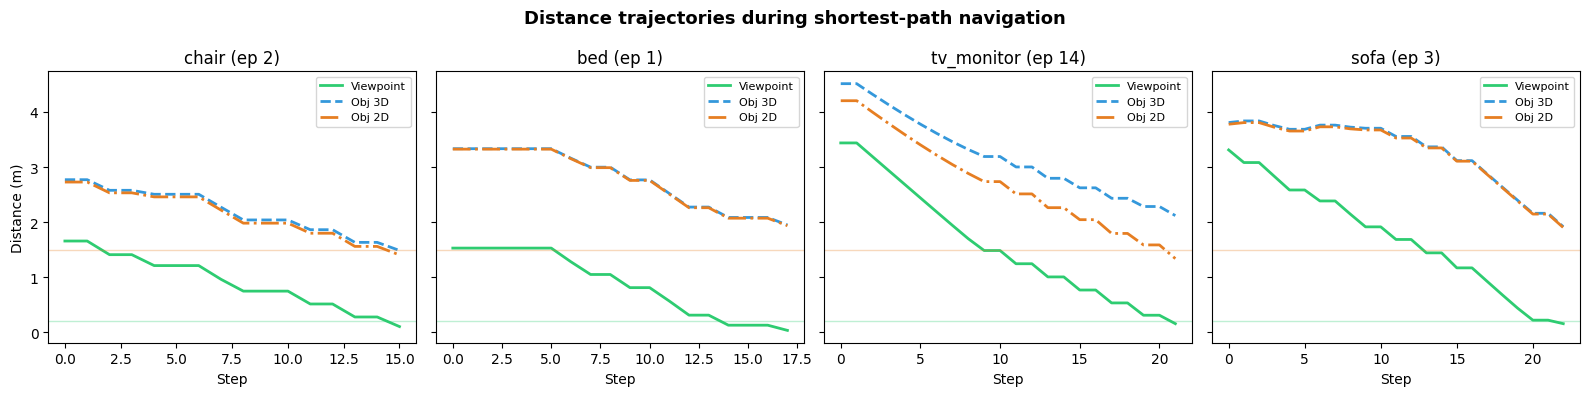

In [10]:
# Pick 4 representative episodes (different categories, successful viewpoint approach)
sample_eps = []
seen_cats = set()
for ep in sorted(good_eps, key=lambda e: e["n_steps"]):
    if ep["category"] not in seen_cats and ep["n_steps"] > 10:
        sample_eps.append(ep)
        seen_cats.add(ep["category"])
    if len(sample_eps) >= 4:
        break

fig, axes = plt.subplots(1, len(sample_eps), figsize=(4 * len(sample_eps), 4),
                         sharey=True)

for ax, ep in zip(axes, sample_eps):
    steps = ep["steps"]
    xs = [s["step"] for s in steps]
    ax.plot(xs, [s["dist_viewpoint"] for s in steps], label="Viewpoint",
            color="#2ecc71", linewidth=2)
    ax.plot(xs, [s["dist_object_3d"] for s in steps], label="Obj 3D",
            color="#3498db", linewidth=2, linestyle="--")
    ax.plot(xs, [s["dist_object_2d"] for s in steps], label="Obj 2D",
            color="#e67e22", linewidth=2, linestyle="-.")
    ax.axhline(0.2, color="#2ecc71", alpha=0.3, linewidth=1)
    ax.axhline(1.5, color="#e67e22", alpha=0.3, linewidth=1)
    ax.set_xlabel("Step")
    ax.set_title(f"{ep['category']} (ep {ep['episode_id']})")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Distance (m)")
fig.suptitle("Distance trajectories during shortest-path navigation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Viewpoint vs object-centroid targeting

What happens when the shortest-path follower navigates toward the **object centroid**
(projected to floor height) instead of the nearest **viewpoint**?

This comparison shows how the choice of navigation target affects final distances
and which success metric/threshold works best for each approach.

In [11]:
if episodes_obj is not None:
    good_vp = [ep for ep in episodes if ep['final_dist_viewpoint'] < 1.0]
    good_obj = [ep for ep in episodes_obj if ep.get('final_dist_viewpoint') is not None]

    # Match episodes by ID for paired comparison
    vp_by_id = {ep['episode_id']: ep for ep in good_vp}
    obj_by_id = {ep['episode_id']: ep for ep in good_obj}
    common_ids = sorted(set(vp_by_id) & set(obj_by_id))

    print(f"Paired episodes: {len(common_ids)}")
    print(f"\n{'':>35} {'--- Viewpoint target ---':>28} {'--- Object centroid target ---':>32}")
    print(f"{'Metric':<35} {'Mean':>6} {'Min':>6} {'Max':>6}   {'Mean':>6} {'Min':>6} {'Max':>6}")
    print('-' * 90)

    for name, key in [('Final viewpoint dist (m)', 'final_dist_viewpoint'),
                       ('Final object 3D dist (m)', 'final_dist_object_3d'),
                       ('Final object 2D dist (m)', 'final_dist_object_2d'),
                       ('Path length (m)', 'path_length'),
                       ('Steps', 'n_steps')]:
        vp_vals = [vp_by_id[eid][key] for eid in common_ids if key in vp_by_id[eid]]
        obj_vals = [obj_by_id[eid][key] for eid in common_ids if key in obj_by_id[eid]]
        if vp_vals and obj_vals:
            vp_a, obj_a = np.array(vp_vals), np.array(obj_vals)
            print(f"{name:<35} {vp_a.mean():>6.2f} {vp_a.min():>6.2f} {vp_a.max():>6.2f}   "
                  f"{obj_a.mean():>6.2f} {obj_a.min():>6.2f} {obj_a.max():>6.2f}")
else:
    print('Object-centroid data not available. Re-run collect_goal_distances.py.')

Paired episodes: 15

                                        --- Viewpoint target ---   --- Object centroid target ---
Metric                                Mean    Min    Max     Mean    Min    Max
------------------------------------------------------------------------------------------
Final viewpoint dist (m)              0.13   0.05   0.20     1.74   0.06   5.05
Final object 3D dist (m)              1.97   1.40   2.74     1.93   0.49   5.33
Final object 2D dist (m)              1.62   1.03   1.98     1.47   0.03   5.09
Path length (m)                       6.82   1.40  21.40     3.19   0.00   5.81
Steps                                68.73  10.00 500.00    21.80   0.00  45.00


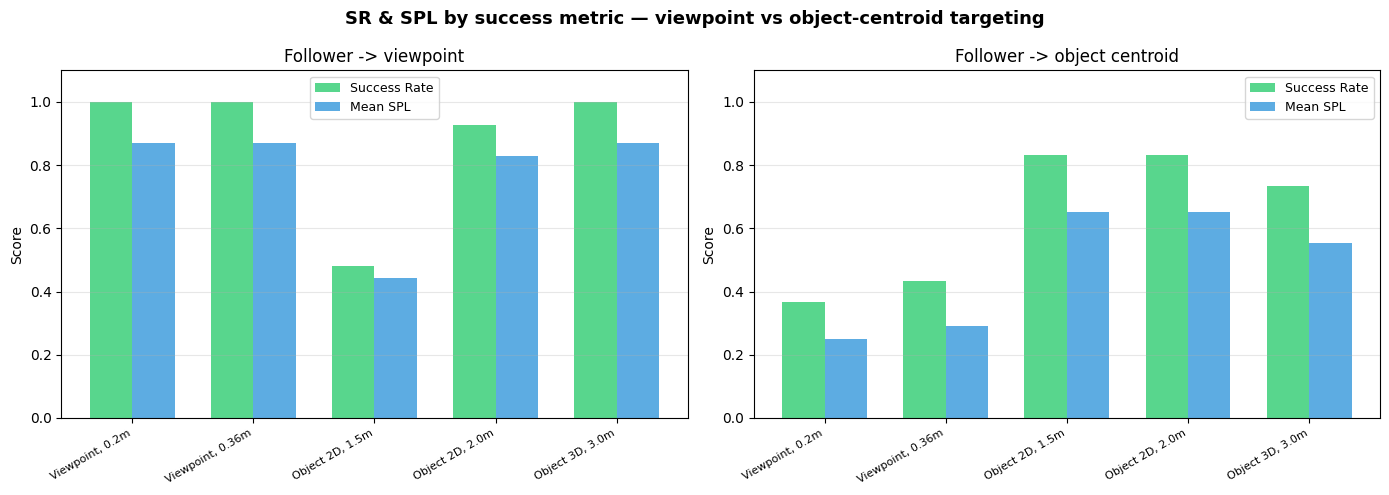

In [12]:
if episodes_obj is not None:
    # SR and SPL comparison across configs for both targeting modes
    configs_cmp = [
        ('Viewpoint, 0.2m',  'dist_viewpoint', 0.2),
        ('Viewpoint, 0.36m', 'dist_viewpoint', 0.36),
        ('Object 2D, 1.5m',  'dist_object_2d', 1.5),
        ('Object 2D, 2.0m',  'dist_object_2d', 2.0),
        ('Object 3D, 3.0m',  'dist_object_3d', 3.0),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (mode_name, mode_eps) in zip(axes, [
        ('Follower -> viewpoint', good_vp),
        ('Follower -> object centroid', good_obj),
    ]):
        names, srs, spls = [], [], []
        for cname, key, thresh in configs_cmp:
            ep_spls = [compute_spl(ep, key, thresh) for ep in mode_eps]
            sr = np.mean([1 if s > 0 else 0 for s in ep_spls])
            mean_spl = np.mean(ep_spls)
            names.append(cname)
            srs.append(sr)
            spls.append(mean_spl)

        x = np.arange(len(names))
        w = 0.35
        ax.bar(x - w/2, srs, w, label='Success Rate', color='#2ecc71', alpha=0.8)
        ax.bar(x + w/2, spls, w, label='Mean SPL', color='#3498db', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('Score')
        ax.set_title(mode_name)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle('SR & SPL by success metric — viewpoint vs object-centroid targeting',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Recommendation

Based on the analysis above, we choose the metric and threshold for our
`HabitatObjectNavEnv` wrapper.

In [13]:
# Summary table: which config gives the optimal agent ~100% SR with meaningful SPL?
print("Criteria for a good success metric:")
print("  1. Shortest-path agent should succeed on ~100% of episodes")
print("  2. SPL should be high (near 1.0) for shortest-path agent")
print("  3. Consistent across object categories")
print("  4. Matches published ObjectNav evaluation standards")
print()

print(f"{'Configuration':<22} {'SR':>6} {'Mean SPL':>10} {'Min SPL':>10}  Notes")
print("-" * 80)
for name, key, thresh in configs:
    spls = [compute_spl(ep, key, thresh) for ep in good_eps]
    sr = np.mean([1 if s > 0 else 0 for s in spls])
    mean_spl = np.mean(spls)
    min_spl = min(spls) if any(s > 0 for s in spls) else 0
    note = ""
    if sr >= 0.95 and mean_spl > 0.5:
        note = "<-- candidate"
    print(f"{name:<22} {sr:>5.0%} {mean_spl:>10.3f} {min_spl:>10.3f}  {note}")

Criteria for a good success metric:
  1. Shortest-path agent should succeed on ~100% of episodes
  2. SPL should be high (near 1.0) for shortest-path agent
  3. Consistent across object categories
  4. Matches published ObjectNav evaluation standards

Configuration              SR   Mean SPL    Min SPL  Notes
--------------------------------------------------------------------------------
Viewpoint, 0.1m          26%      0.238      0.000  
Viewpoint, 0.2m         100%      0.870      0.172  <-- candidate
Viewpoint, 0.36m        100%      0.870      0.172  <-- candidate
Object 3D, 1.0m           0%      0.000      0.000  
Object 3D, 2.0m          56%      0.507      0.000  
Object 3D, 3.0m         100%      0.870      0.172  <-- candidate
Object 2D, 1.0m           0%      0.000      0.000  
Object 2D, 1.5m          48%      0.443      0.000  
Object 2D, 2.0m          93%      0.828      0.000  
